# Problem: Implement an LSTM Model 

### Problem Statement
You are tasked with implementing a simple **LSTM (Long Short-Term Memory)** model in PyTorch. The model should process sequential data using an LSTM layer followed by a fully connected (FC) layer. Your goal is two-fold: one is to implement a LSTM layer from scratch and another using inbuilt pytorch LSTM layer. Compare the results implementing the forward passes for both the LSTM models.

### Requirements
1. **Define the LSTM Model using Custom LSTM layer**:
   - Add a `Custom` LSTM layer to the model. The layer must take care of the hidden and cell states
   - Add a **fully connected (FC) layer** that maps the output of the LSTM to the final predictions.
   - Implement the `forward` method to:
     - Pass the input sequence through the LSTM.
     - Feed the output of the LSTM into the fully connected layer for the final output.

2. **Define the LSTM Model using in-built LSTM layer**:
  - Same as `1` with only difference that this time define the LSTM layer using pytorch `nn.Module`

### Constraints
- The LSTM layer should be implemented with a single hidden layer.
- Use a suitable number of input features, hidden units, and output size for the task.
- Make sure the `forward` method returns the output of the fully connected layer after processing the LSTM output.


<details>
  <summary>💡 Hint</summary>
  Add the LSTM layer and FC layer in LSTMModel.__init__.
  <br>
  Implement the forward pass to process sequences using the LSTM and FC layers.
  <br> Review Hidden and cell states computation here: [D2l.ai](https://d2l.ai/chapter_recurrent-modern/lstm.html)
</details>

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [70]:
# Generate synthetic sequential data
torch.manual_seed(42)
sequence_length = 10
num_samples = 100

# Create a sine wave dataset
seq = torch.sin(torch.linspace(0, 4 * 3.14159, steps=num_samples)).unsqueeze(1)

# Prepare data for LSTM
def create_in_out_sequences(data, seq_length):
    in_seq = []
    out_seq = []
    for i in range(len(data) - seq_length):
        in_seq.append(data[i:i + seq_length])
        out_seq.append(data[i + seq_length])
    return torch.stack(in_seq), torch.stack(out_seq)

X_seq, Y_seq = create_in_out_sequences(seq, sequence_length)

In [137]:
# Define the LSTM Model
# TODO: Add LSTM layer, forward implementation
DIM_IN = 1
DIM_HIDDEN = 128
DIM_OUT = 1
NUM_LAYERS = 2

In [138]:
class CustomLSTMModel(nn.Module):
    def __init__(self):
        super(CustomLSTMModel, self).__init__()

        self.ww = nn.ModuleList()
        self.uu = nn.ModuleList()
        for i in range(NUM_LAYERS):
            self.ww.append(nn.Linear(DIM_HIDDEN, DIM_HIDDEN * 4))
            self.uu.append(nn.Linear(DIM_IN if i == 0 else DIM_HIDDEN, DIM_HIDDEN * 4, bias=False))

        self.projection = nn.Linear(DIM_HIDDEN, DIM_OUT)

    def forward(self, x, cc_hh=None):
        N, T, D = x.shape

        if cc_hh:
            cc, hh = cc_hh
        else:
            cc = torch.zeros(NUM_LAYERS, N, DIM_HIDDEN)
            hh = torch.zeros(NUM_LAYERS, N, DIM_HIDDEN)

        cc_out = []
        hh_out = []
        
        for i in range(NUM_LAYERS):
            outputs = []
            c, h = cc[i], hh[i]
            w, u = self.ww[i], self.uu[i]
            for t in range(T):
                gf, gi, go, cn = torch.chunk(w(h) + u(x[:, t, :]), chunks=4, dim=-1)
                gf = torch.sigmoid(gf)
                gi = torch.sigmoid(gi)
                go = torch.sigmoid(go)
                cn = torch.tanh(cn)
                c = gf * c + gi * cn
                h = go * torch.tanh(c)
                outputs.append(h)
            x = torch.stack(outputs, dim=1)
            cc_out.append(c)
            hh_out.append(h)

        return self.projection(x), (torch.stack(cc_out, dim=0), torch.stack(hh_out, dim=0))

In [139]:
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=DIM_IN, hidden_size=DIM_HIDDEN, num_layers=NUM_LAYERS, batch_first=True)
        self.projection = nn.Linear(DIM_HIDDEN, DIM_OUT)

    def forward(self, x, c_h=None):
        N, T, D = x.shape

        if c_h:
            c, h = c_h
        else:
            c = torch.zeros(NUM_LAYERS, N, DIM_HIDDEN)
            h = torch.zeros(NUM_LAYERS, N, DIM_HIDDEN)

        hs, (c,h) = self.lstm(x, (c,h))
        return self.projection(hs), (c,h)

In [140]:
# Initialize the model, loss function, and optimizer
model_custom = CustomLSTMModel()
model_inbuilt = LSTMModel()

def train(model):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Training loop
    epochs = 500
    for epoch in range(epochs):
        # Forward pass
        predictions, _ = model(X_seq)
        loss = criterion(predictions[:, -1, :], Y_seq)
    
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        # Log progress every 50 epochs
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

print("custom:")
train(model_custom)
print("buildin:")
train(model_inbuilt)

custom:
Epoch [50/500], Loss: 0.0004
Epoch [100/500], Loss: 0.0000
Epoch [150/500], Loss: 0.0000
Epoch [200/500], Loss: 0.0000
Epoch [250/500], Loss: 0.0000
Epoch [300/500], Loss: 0.0000
Epoch [350/500], Loss: 0.0000
Epoch [400/500], Loss: 0.0000
Epoch [450/500], Loss: 0.0000
Epoch [500/500], Loss: 0.0000
buildin:
Epoch [50/500], Loss: 0.0006
Epoch [100/500], Loss: 0.0000
Epoch [150/500], Loss: 0.0000
Epoch [200/500], Loss: 0.0000
Epoch [250/500], Loss: 0.0000
Epoch [300/500], Loss: 0.0000
Epoch [350/500], Loss: 0.0000
Epoch [400/500], Loss: 0.0000
Epoch [450/500], Loss: 0.0000
Epoch [500/500], Loss: 0.0000


In [131]:
# Testing on new data
steps = 137  # Ensure this is greater than sequence_length
seq = torch.sin(torch.linspace(4.29 * 3.14159, 6.83 * 3.14159, steps=num_samples)).unsqueeze(1)

# Create test input sequences
X_seq, Y_seq = create_in_out_sequences(seq, sequence_length)

ground_truth = torch.flatten(Y_seq)

with torch.no_grad():
    pred_custom, _ = model_custom(X_seq)
    pred_inbuilt, _ = model_inbuilt(X_seq)
pred_custom = torch.flatten(pred_custom[:, -1, :])
pred_inbuilt = torch.flatten(pred_inbuilt[:, -1, :])

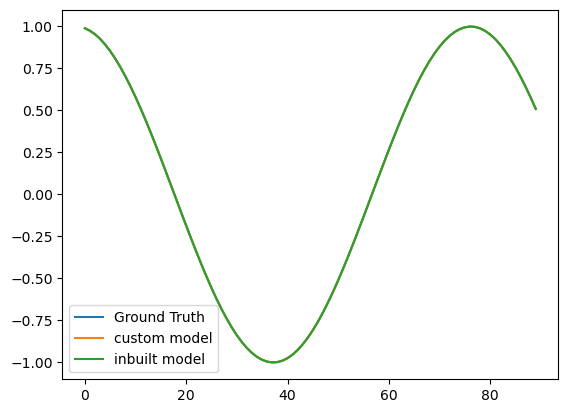

In [133]:
#Plot the predictions
plt.figure()
plt.plot(ground_truth, label="Ground Truth")
plt.plot(pred_custom, label="custom model")
plt.plot(pred_custom, label="inbuilt model")
plt.legend()
plt.show()

In [134]:
pred_custom - pred_inbuilt

tensor([ 1.0024e-03,  8.3762e-04,  5.3096e-04,  1.1438e-04, -3.5095e-04,
        -7.7957e-04, -1.0723e-03, -1.1405e-03, -9.3424e-04, -4.6909e-04,
         1.6111e-04,  7.9924e-04,  1.2741e-03,  1.4540e-03,  1.2923e-03,
         8.3624e-04,  2.1082e-04, -4.2905e-04, -9.4556e-04, -1.2505e-03,
        -1.3066e-03, -1.1279e-03, -7.6950e-04, -3.1438e-04,  1.5512e-04,
         5.7161e-04,  8.9175e-04,  1.0943e-03,  1.1715e-03,  1.1219e-03,
         9.4450e-04,  6.5142e-04,  2.6953e-04, -1.5962e-04, -5.8281e-04,
        -9.4497e-04, -1.1962e-03, -1.3012e-03, -1.2454e-03, -1.0341e-03,
        -6.9296e-04, -2.6500e-04,  1.9413e-04,  6.2090e-04,  9.5266e-04,
         1.1354e-03,  1.1354e-03,  9.4658e-04,  5.9760e-04,  1.5324e-04,
        -2.9474e-04, -6.4769e-04, -8.2499e-04, -7.9060e-04, -5.6005e-04,
        -2.0817e-04,  1.5923e-04,  4.4416e-04,  5.8775e-04,  5.8368e-04,
         4.7004e-04,  3.0452e-04,  1.3545e-04, -8.4639e-06, -1.3077e-04,
        -2.4754e-04, -3.6985e-04, -4.9424e-04, -5.9

In [135]:
model_custom

CustomLSTMModel(
  (ww): ModuleList(
    (0-1): 2 x Linear(in_features=128, out_features=512, bias=True)
  )
  (uu): ModuleList(
    (0): Linear(in_features=1, out_features=512, bias=False)
    (1): Linear(in_features=128, out_features=512, bias=False)
  )
  (projection): Linear(in_features=128, out_features=1, bias=True)
)

In [136]:
model_inbuilt

LSTMModel(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True)
  (projection): Linear(in_features=128, out_features=1, bias=True)
)